# Photometric points : VHS 1256 b

This demo is intended as a quick start when using photometric data.  
We will use several photometric points of VHS 1256 b obtained with different facilities. The filters considered here are: 

- Paranal
    - SPHERE
        - IRDIS_D_H23_2
        - IRDIS_D_H23_3
        - IRDIS_D_K12_1
        - IRDIS_D_K12_2
    - NACO
        - Lp
        - NB405
        - Mp
          
- JWST
    - NIRCam
        - F250M
        - F300M
        - F356W
        - F410M
        - F444W
    - MIRI
        - F1140C
        - F1550C

Be sure that ForMoSA is in your environment. If you installed ForMoSA from GitHub and added it locally to your `$PYTHONPATH`, you want Jupyter to be able to read it. To do that, please run these two lines in your terminal before launching Jupyter Notebook:

```bash
echo 'export PYTHONPATH="/YOUR/PATH/TO/FORMOSA:$PYTHONPATH"' >> $CONDA_PREFIX/etc/conda/activate.d/env_vars.sh
mkdir -p \$CONDA_PREFIX/etc/conda/activate.d
```

Also, check that the kernel of your Jupyter Notebook corresponds to the kernel of your local environment.

Finally, verify that you input data is at the correct format described in [Guidelines](https://formosa.readthedocs.io/en/latest/demo.html)


## Imports

In [1]:
from ForMoSA.analysis import Analysis
from ForMoSA.core.config import set_filter_path, PlotsConfig, SPECTRAL_PLOT, PHOTOMETRIC_PLOT
from ForMoSA.config.global_config import ConfigLoader, ConfigGenerator, Config_NS

## Root path of your analysis
Please, copy the demo repository into your ForMoSA working environement

In [3]:
demo_path = '/Users/spetrus/Desktop/ForMoSA_pkg/ForMoSA/docs/demos/photo/'
formosa_working_path = '/Users/spetrus/Desktop/ForMoSA_pkg/photo/'

import shutil
shutil.copytree(demo_path, formosa_working_path)

# ---- Path where to store photometric filter data ----
# No need to create the folder, ForMoSA will create it for you
# You can avoid this step. In that case the folder will be created at ~/.
set_filter_path(formosa_working_path + '/filters')

## Generation of your configuration file
If this is the first time you are fitting your data, you will need a configuration file. This file can be generated automatically with default parameters using:

In [4]:
generator = ConfigGenerator()
generator.save(formosa_working_path, 'vhs1256b/new_config.ini')

INFO         Save config to path /Users/spetrus/Desktop/ForMoSA_pkg/photo/

## Modification of your configuration file

You may want to adapt your configuration file to your analysis. You can do it manually or using this routine. You are encouraged to check the config.ini file to see if you need to modify any other parameters.

In [5]:
config_r = open(formosa_working_path + 'vhs1256b/new_config.ini', "rt")
conf = config_r.read()

# Change the path of your data
conf = conf.replace("observation_path = unknown", "observation_path = " + formosa_working_path + "vhs1256b/data/")

# Change the location of the grid after its adaptation to your data
conf = conf.replace("adapt_store_path = unknown", "adapt_store_path = " + formosa_working_path + "adapted_grid/")

# Change the path where the results will be stored after the fit
conf = conf.replace("result_path = unknown", "result_path = " + formosa_working_path + "vhs1256b/results/")

# Change the path of the initial grid. In our case it will be the grid BT-Settl. See the tutorial for downloading it.
path_grid = '/Users/spetrus/Desktop/models_grids/BTSETTL_native.nc'
conf = conf.replace("model_path = unknown", "model_path = " + path_grid)

config_r.close()
config_w = open(formosa_working_path + 'vhs1256b/new_config.ini', "wt")
config_w.write(conf)
config_w.close()

With these lines, you can check the properties of the grid you have selected. This will help you define the parameter space explored by your fit. In our case, the BT-Settl grid explores two parameters:

Teff = 1200, 3000 K

log(g) = 2.5, 5.5 dex

In [7]:
config_r = open(formosa_working_path + 'vhs1256b/new_config.ini', "rt")
conf = config_r.read()

# Change the wavelength range considered for the fit
conf = conf.replace('wav_fit = "0.9, 5.0"', 'wav_fit = "2.0, 16.0"')

# Change the paramter space explored by the nested sampling
conf = conf.replace('par1 = NA,', 'par1 = uniform, 1200, 2800,')
conf = conf.replace('par2 = NA,', 'par2 = uniform, 2.5, 5.5,')

# Change the number of living points.   
conf = conf.replace('npoints = 50', 'npoints = 100')

# Change the nested sampling algorithm (/!\ only nestle seems to work with jupyter. Launche ForMoSA from a terminal to use the other ones)
conf = conf.replace('ns_algo = pymultinest', 'ns_algo = nestle')

config_r.close()
config_w = open(formosa_working_path + 'vhs1256b/new_config.ini', "wt")
config_w.write(conf)
config_w.close()

## Loading of the configuration file

You have to load the configuration file and pass it to all algorithms. The Nested Sampling class will use only the parameters relevant to the algorithm you are using. You should also save this configuration file to ensure it is consistent with your results.

In [8]:
cfg = ConfigLoader(formosa_working_path + 'vhs1256b/new_config.ini')
sections = cfg.load()

config_ns = Config_NS(
            nestle=cfg.config['config_nestle'],
            pymultinest=cfg.config['config_pymultinest'],
            ultranest=cfg.config['config_ultranest']
            )

generator = ConfigGenerator(sections)
generator.save(cfg.config['config_path'].result_path)

INFO         Config file loaded

INFO         Save config to path /Users/spetrus/Desktop/ForMoSA_pkg/photo/vhs1256b/results/

## Preparation of the analysis

You need to define you analysis plan by defining two variables.

In [9]:
import os
import shutil

# If this is the first time you are adapting your model grid, or if you need to re-adapt it, set adapted = False
# If you have already adapted your model grid, set adapted = True
adapted = False
if adapted == False:
    shutil.rmtree(formosa_working_path + "adapted_grid/")
    os.mkdir(formosa_working_path + "adapted_grid/")

# If you want to perform the fit, set fitted = False
# If you only want to generate plots, set fitted = True
fitted = False

analysis = Analysis(cfg.config['config_path'], adapted=adapted, fitted=fitted)

INFO         Paths checked

INFO         ModelGrid generated from /Users/spetrus/Desktop/models_grids/BTSETTL_native.nc

WARNING  Wavelength unit not found in grid attributes. Setting to default: um

/Users/spetrus/Desktop/ForMoSA_pkg/ForMoSA/ForMoSA/grid/model_grid.py:162: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return list(self.grid.dims.values())
<frozen _collections_abc>:880: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
/Users/spetrus/Desktop/ForMoSA_pkg/ForMoSA/ForMoSA/grid/model_grid.py:158: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return list(self.grid.dims.keys())


INFO         Grid dimensions: (1161983, 22, 7) ('wavelength', 'par1', 'par2')

...

INFO         Setting wavelength unit to um for filter JWST/MIRI.F1140C to um

INFO         Filter data for JWST/MIRI.F1550C successfully found

INFO         Setting wavelength unit to um for filter JWST/MIRI.F1550C to um

INFO           Adding Photometric Observation with name [JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters] to the
         set of observations

INFO         Set of Observations generated

In [10]:
print(analysis.observations.observations[0].Filter[0].filter_path)

/Users/spetrus/filters


## Launch of the adaptation

The grid and the observations will be modified to make them comparable. This step should take less than 10 seconds with this setup, data, and model.

In [11]:
analysis.adapt(cfg.config['config_adapt'], cfg.config['config_inversion'])

INFO         Adapting Observation: [JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters]

INFO           Observation [JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters] is photometric. No adaptation

INFO         Observations ['[JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters]'] adapted

INFO         Saving all the observations ['[JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters]'] to path          
         /Users/spetrus/Desktop/ForMoSA_pkg/photo/vhs1256b/results/Observations

INFO           Saving Observation Observation_[JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters].npz

...

INFO      1/2 - Teff

INFO      2/2 - log(g)

WARNING  path /Users/spetrus/Desktop/ForMoSA_pkg/photo/adapted_grid/Subgrids does not exist. Creating it

INFO         Saving all the subgrids                                                                               
         ['BTSETTL_native_[JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters]_Photometric'] to path               
         /Users/spetrus/Desktop/ForMoSA_pkg/photo/adapted_grid/Subgrids

INFO         Saving Grid adapted_BTSETTL_native_[JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters]_Photometric.nc
         to /Users/spetrus/Desktop/ForMoSA_pkg/photo/adapted_grid/Subgrids

## Launch of the inversion

The fit will be performed using the chosen nested sampling algorithm. This step should take less than 30 seconds with this setup, data, and model.

In [12]:
analysis.nested_sampling(cfg.config['config_parameters'], cfg.config['config_adapt'], cfg.config['config_inversion'], config_NS=config_ns)

INFO           Detected grid Parameter with name par1 from config

INFO             Adding grid Parameter with name par1 to the set of parameters

INFO           Detected grid Parameter with name par2 from config

INFO             Adding grid Parameter with name par2 to the set of parameters

INFO         Set of parameters generated

...

INFO         Creating directory /Users/spetrus/Desktop/ForMoSA_pkg/photo/vhs1256b/results

INFO         Summary for the Nested Sampling parameters:                                                           
             name  kind    prior             value  fixed   scope obs_index                                        
         0  par1  GRID  uniform  [1200.0, 2800.0]  False  global      None                                         
         1  par2  GRID  uniform        [2.5, 5.5]  False  global      None

it=   557 logz=-16.2113280

INFO         Time spent: 35.559372901916504

INFO         Saving results

## Plot of your results

You are free to modify the plot parameters using the following lines (examples). The outputs are saved in the results folder if you want to create your own plots.

INFO         Plotting Corner plot

INFO         Plotting posterior chains for each parameter.

INFO         Plotting radar plot of the chains

INFO         Plotting best fit and residuals

INFO           Adding Photometric Observation with name [JWST+Paranal]_[MIRI+NACO+NIRCam+SPHERE]_[14filters] to the
         set of observations

...

INFO           Plotting transmission curve of filter JWST/NIRCam.F410M

INFO           Plotting transmission curve of filter JWST/NIRCam.F444W

INFO           Plotting transmission curve of filter Paranal/NACO.Mp

INFO           Plotting transmission curve of filter JWST/MIRI.F1140C

INFO           Plotting transmission curve of filter JWST/MIRI.F1550C

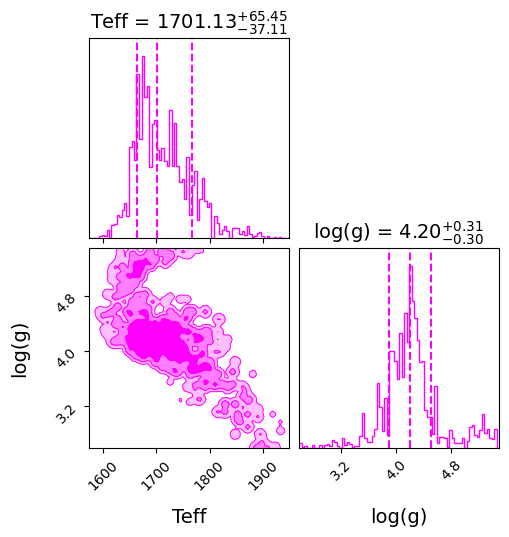

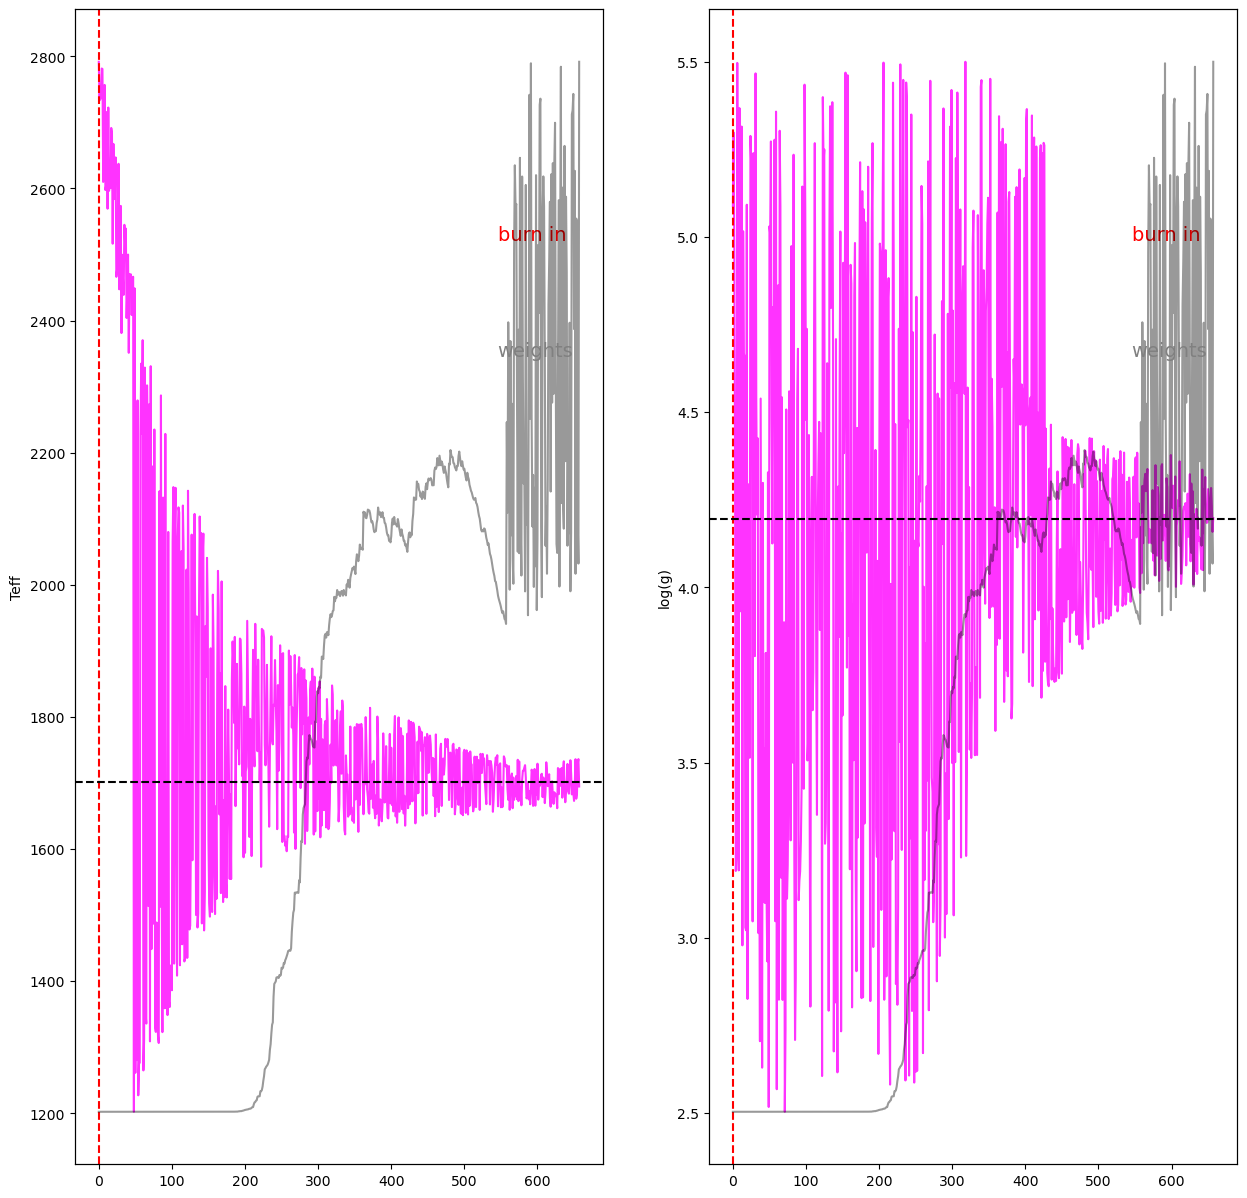

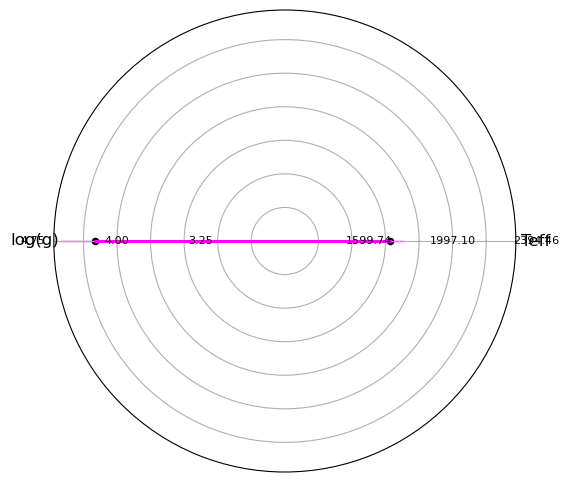

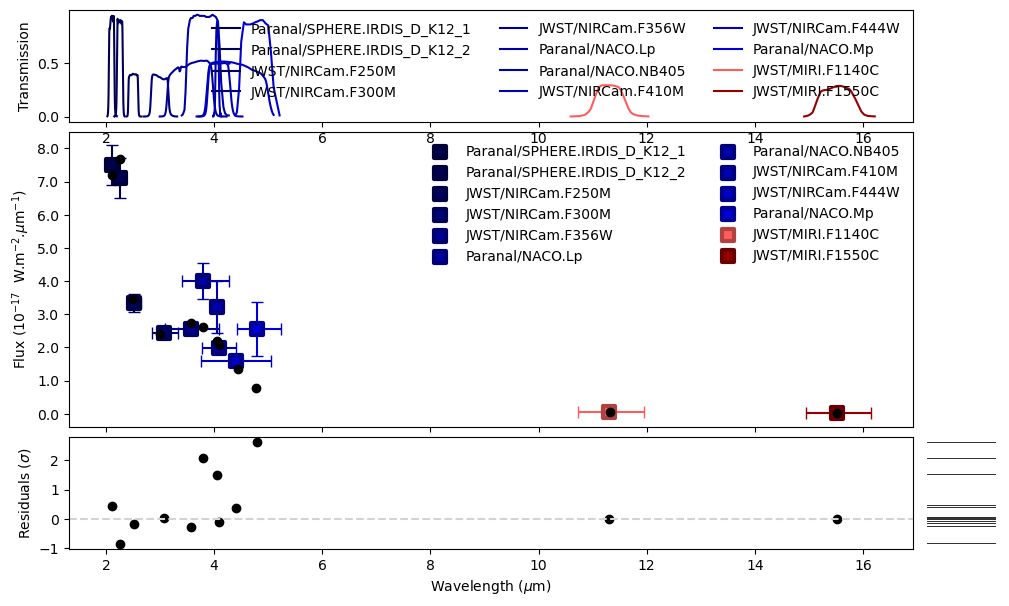

In [13]:
SPECTRAL_PLOT.markersize = 0
PHOTOMETRIC_PLOT.linewidth = 3
analysis.plot(analysis.ns.results, plot_native_model=False)